In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\uktiw\Downloads\New folder\insurance_synthetic_data.xls")
df.head(5)

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,charges
0,56,male,23.5,153,Yes,2,No,northeast,28309.76,24457.66
1,46,male,28.1,133,No,2,No,southwest,19454.47,17312.84
2,32,male,26.4,142,Yes,1,No,southeast,25998.33,21362.60
3,60,male,25.9,113,Yes,3,No,northeast,29782.52,26696.27
4,25,male,30.1,149,Yes,4,Yes,northwest,37532.64,35255.83


### Q1: What are the dimensions of the dataset (rows & columns)?

In [3]:
df.shape

(500, 10)

### Q2: What are the data types of each column?

In [5]:
df.dtypes

age                int64
gender            object
bmi              float64
bloodpressure      int64
diabetic          object
children           int64
smoker            object
region            object
claim            float64
charges          float64
dtype: object

### Q3: Identify numerical and categorical columns.

In [7]:
numerical_cols = df.select_dtypes(include = ['number'])
numerical_cols

,age,bmi,bloodpressure,children,claim,charges
0,56,23.5,153,2,28309.76,24457.66
1,46,28.1,133,2,19454.47,17312.84
2,32,26.4,142,1,25998.33,21362.60
3,60,25.9,113,3,29782.52,26696.27
4,25,30.1,149,4,37532.64,35255.83
...,...,...,...,...,...,...
495,37,29.3,143,3,17240.05,20121.49
496,41,29.8,141,3,34912.47,30287.79
497,29,29.2,92,1,14038.61,14084.07
498,52,30.2,130,1,19721.48,21462.30


In [8]:
categorical_cols = df.select_dtypes(include = ['object'])
categorical_cols

,gender,diabetic,smoker,region
0,male,Yes,No,northeast
1,male,No,No,southwest
2,male,Yes,No,southeast
3,male,Yes,No,northeast
4,male,Yes,Yes,northwest
...,...,...,...,...
495,male,No,No,southeast
496,male,No,Yes,southeast
497,female,No,No,southeast
498,male,No,No,northeast


### Q4: Are there any missing values in the dataset?

In [9]:
df.isnull().sum()

age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
charges          0
dtype: int64

### Q5: How many unique values are present in each categorical column?

In [10]:
df.select_dtypes(include = 'object').nunique()

gender      2
diabetic    2
smoker      2
region      4
dtype: int64

In [13]:
categorical_cols
for i in categorical_cols:
    print(i,df[i].nunique())

gender 2
diabetic 2
smoker 2
region 4


In [14]:
categorical_cols.nunique()

gender      2
diabetic    2
smoker      2
region      4
dtype: int64

### Q6: What is the distribution of premium?

In [15]:
df = df.rename(columns = {'charges':'premium'})
df.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,premium
0,56,male,23.5,153,Yes,2,No,northeast,28309.76,24457.66
1,46,male,28.1,133,No,2,No,southwest,19454.47,17312.84
2,32,male,26.4,142,Yes,1,No,southeast,25998.33,21362.60
3,60,male,25.9,113,Yes,3,No,northeast,29782.52,26696.27
4,25,male,30.1,149,Yes,4,Yes,northwest,37532.64,35255.83


Text(0.5, 1.0, 'Distribution of Premium')

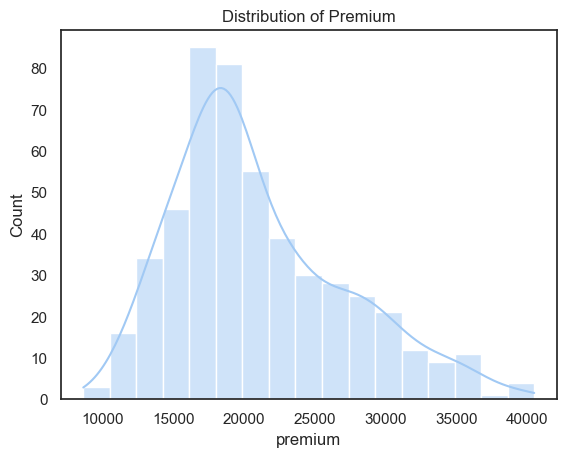

In [22]:
sns.set_theme(style='white',palette='pastel')
sns.histplot(x='premium',data=df,kde = True)
plt.title("Distribution of Premium")

15k - 20k of premium range is in highest count

### Q7: Is the distribution of premium skewed? If yes, in which direction?

Text(0.5, 1.0, 'Distribution of Premium')

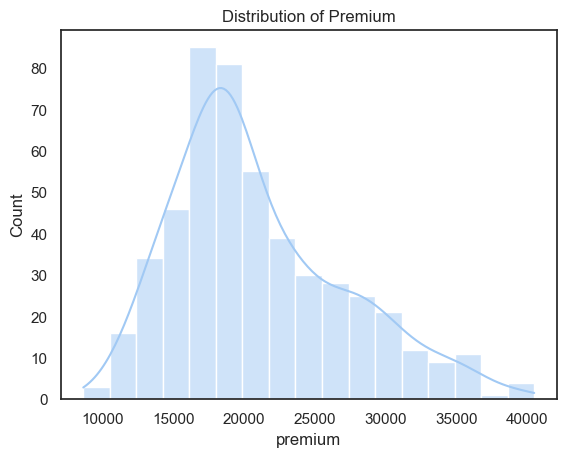

In [23]:
##yes it Skewed and it skewe in right direction
sns.set_theme(style='white',palette='pastel')
sns.histplot(x='premium',data=df,kde = True)
plt.title("Distribution of Premium")

Yes, it Skewed and it skewe in right direction

### Q8: What are the summary statistics of premium?

In [20]:
df['premium'].describe()

count      500.000000
mean     20978.795180
std       6078.386111
min       8636.040000
25%      16750.982500
50%      19453.720000
75%      24394.202500
max      40510.960000
Name: premium, dtype: float64

### Q9: Are there any outliers in premium?

Text(0.5, 1.0, 'Boxplot of Premium')

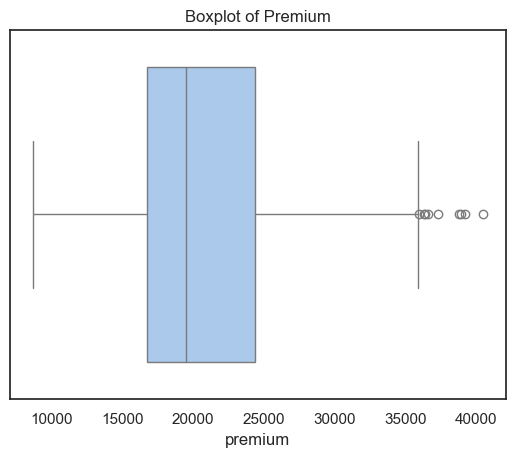

In [25]:
sns.boxplot(x = 'premium', data = df)
plt.title("Boxplot of Premium")

The boxplot shows several outlier points in premium values,indicating unusually high premiums compared to the majority.

### Q10: What is the distribution of age?

Text(0.5, 1.0, 'Distribution of age')

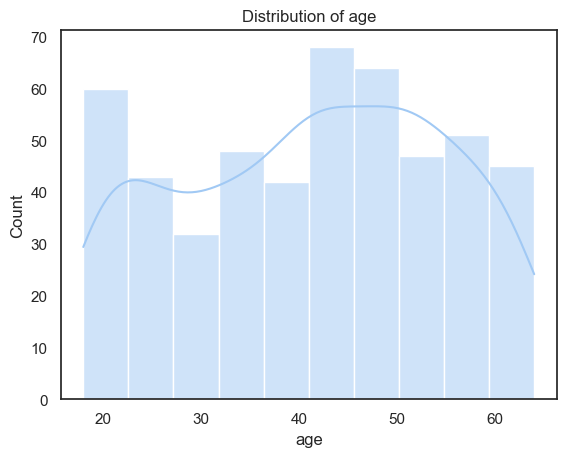

In [27]:
sns.histplot( x = 'age',data =df,kde = True) 
plt.title("Distribution of age")

 The histogram shows that most ages cluster around 40–50,with fewer counts at younger and older ranges.

### Q11: What is the distribution of BMI?

Text(0.5, 1.0, 'Distribution of bmi')

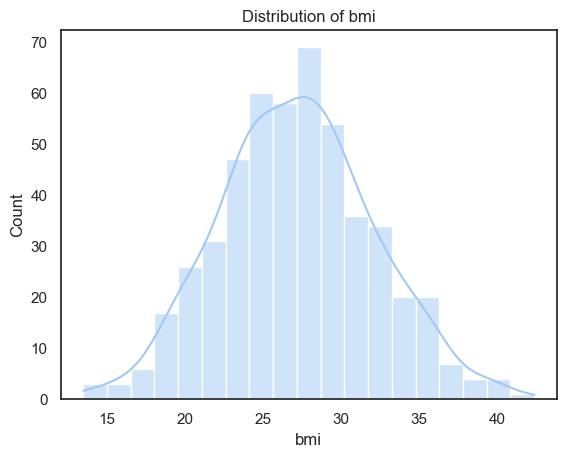

In [36]:
sns.histplot( x = 'bmi',data =df,kde = True) 
plt.title("Distribution of bmi")

The histogram shows BMI values mostly centered around 25–30,forming a roughly normal distribution with few extremes.



### Q12: What is the distribution of number of children?

<Axes: xlabel='children', ylabel='count'>

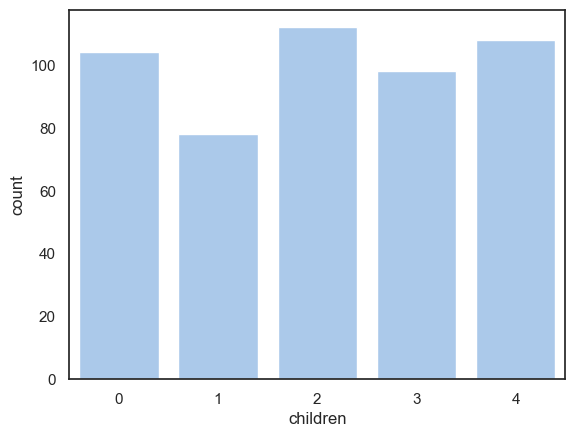

In [28]:
sns.countplot(x = 'children', data = df)

 The countplot reveals a fairly balanced distribution of family sizes, 
 with 2 children being the most common. Interestingly, households with 
 0 and 4 children also appear frequently, while 1 and 3 children are 
 slightly less represented, suggesting diverse family structures in the dataset.


### Q13: What is the gender distribution?

<Axes: xlabel='gender', ylabel='count'>

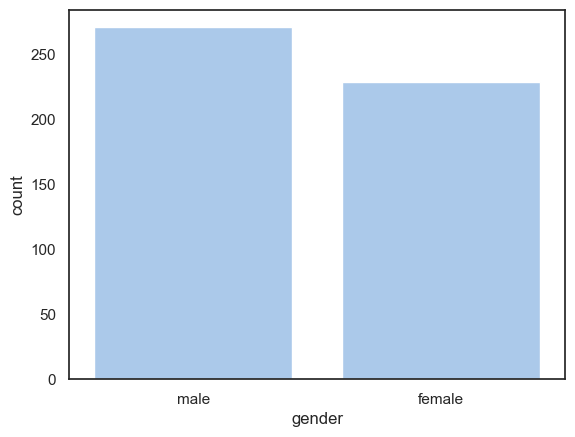

In [29]:
sns.countplot(x= 'gender' , data = df)

 The countplot indicates a relatively balanced gender distribution, 
 with males slightly outnumbering females in the dataset.


### Q14: What is the smoker distribution?

<Axes: xlabel='smoker', ylabel='count'>

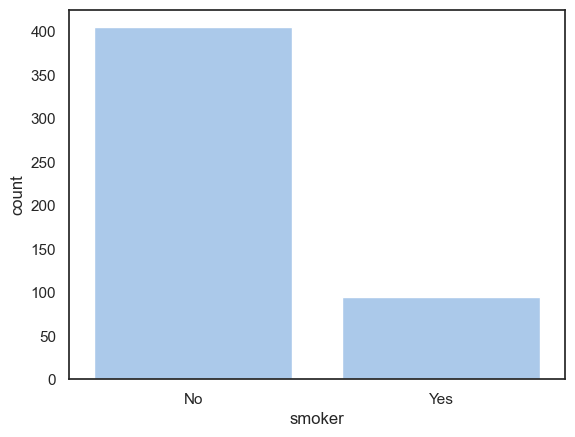

In [30]:
sns.countplot(x= 'smoker' , data = df)

The countplot shows that most individuals in the dataset are non-smokers, while smokers make up a much smaller portion.

### Q15: What is the region distribution?

<Axes: xlabel='region', ylabel='count'>

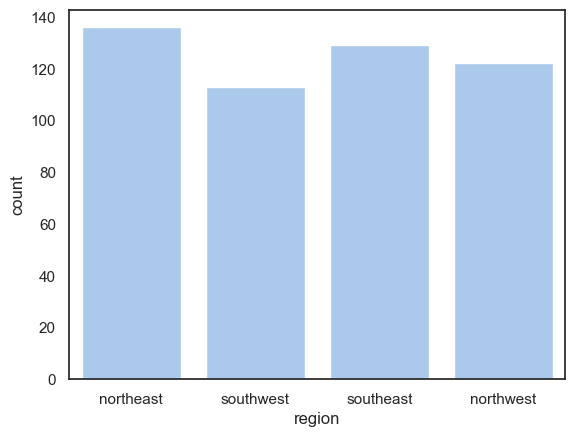

In [31]:
sns.countplot(x= 'region' , data = df)

The countplot shows that the northeast region has the highest representation, while the southwest has the lowest, with the other regions distributed fairly evenly in between.

### Q16: Does smoking affect medical charges?

Text(0.5, 1.0, 'Medical premium by Smoking Status')

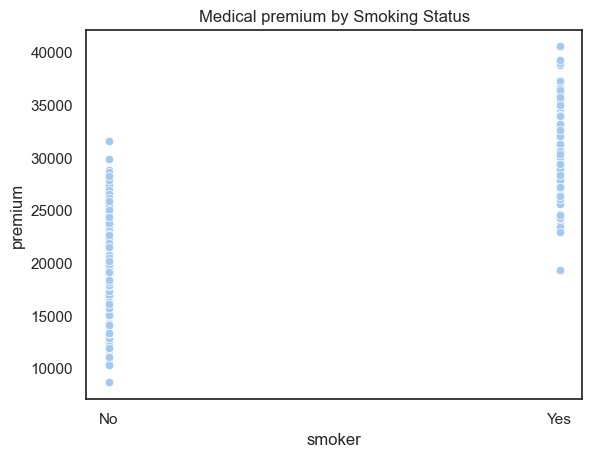

In [55]:
sns.scatterplot(x='smoker', y='premium', data=df)
plt.title('Medical premium by Smoking Status')

Smokers are associated with noticeably higher medical premiums compared to non‑smokers, showing a clear impact of smoking on charges.

### Q17: What is the relationship between BMI and charges?

<Axes: xlabel='premium', ylabel='bmi'>

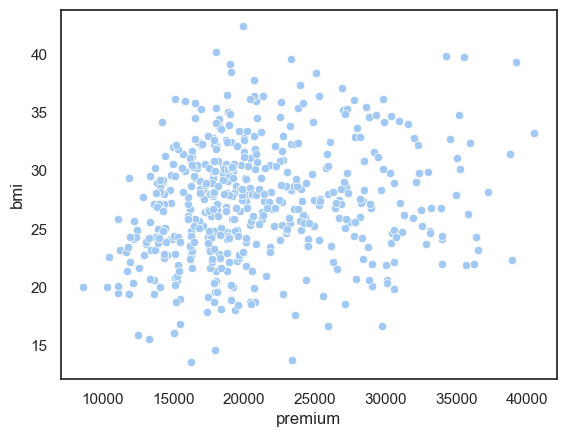

In [54]:
sns.scatterplot(x= 'premium', y = 'bmi', data = df)

There appears to be a **slight positive relationship** between BMI and medical premiums, as higher BMI values tend to correspond with somewhat higher charges, though the pattern is scattered and not strongly pronounced.

### Q18: How does smoking influence the BMI vs charges relationship?

Text(0.5, 1.0, 'BMI vs premium by Smoking Status')

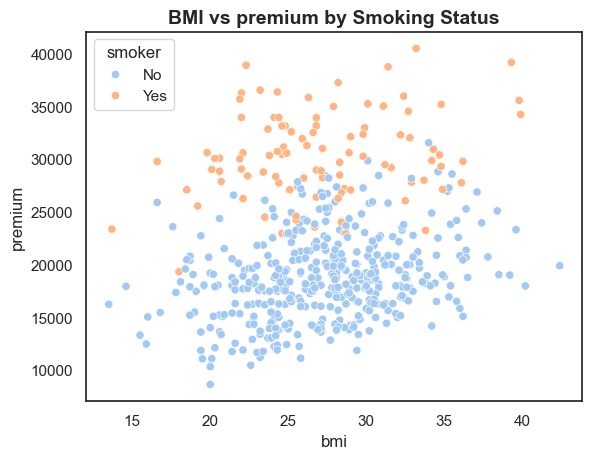

In [71]:
sns.scatterplot(x='bmi', y='premium',hue= 'smoker',data=df)
plt.title('BMI vs premium by Smoking Status', fontsize=14, fontweight='bold')

Smokers consistently show higher premiums across BMI levels, indicating that smoking amplifies medical costs regardless of body mass.

### Q19: What is the relationship between age and charges?

<Axes: xlabel='age', ylabel='premium'>

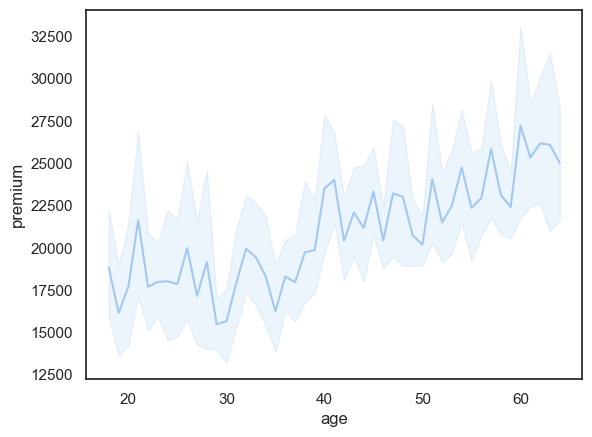

In [56]:
sns.lineplot(x = 'age', y = 'premium', data = df)

There is a clear upward trend showing that medical premiums generally increase with age, reflecting higher charges for older individuals.

### Q20: Do males and females differ in premium?

<Axes: xlabel='gender', ylabel='premium'>

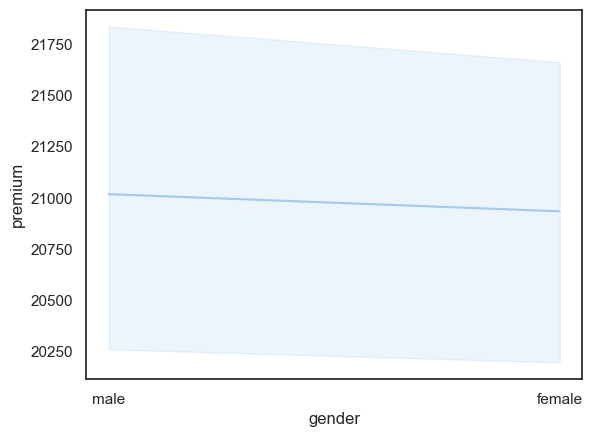

In [60]:
sns.lineplot(x= 'gender', y= 'premium', data = df)

The comparison shows that average premiums are slightly higher for males than females, though the difference is small.

### Q21: Does the number of children affect charges?

<Axes: xlabel='children', ylabel='premium'>

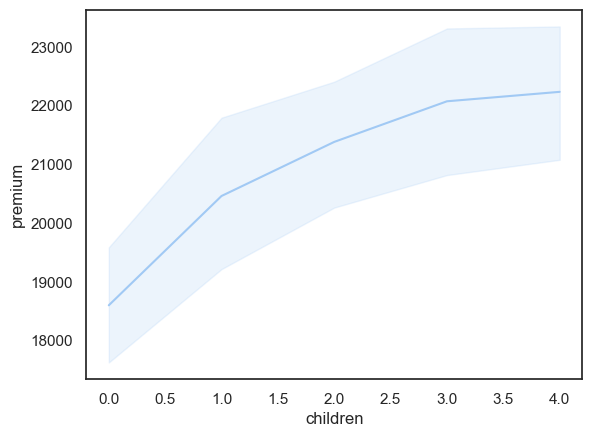

In [72]:
sns.lineplot(x= 'children', y= 'premium', data = df)

The analysis shows that premiums tend to rise as the number of children increases, suggesting a positive relationship between family size and medical charges.

### Q22: Does region affect premium?

<Axes: xlabel='region', ylabel='premium'>

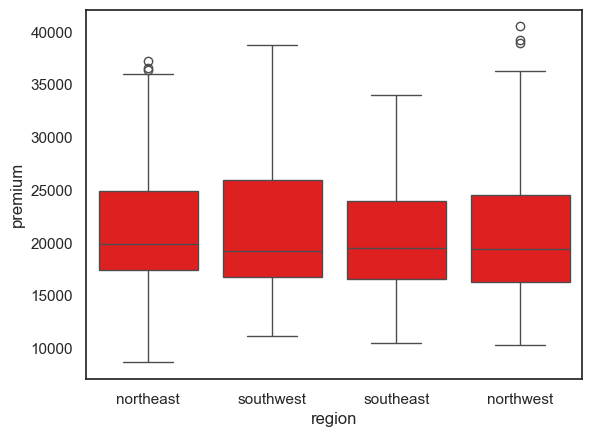

In [70]:
sns.boxplot(x= 'region', y = 'premium' , data= df, color = 'red')

Premiums vary across regions, but the differences are not very large, suggesting that geographic location has only a modest influence on charges.

### Q23: What are the pairwise relationships between variables?

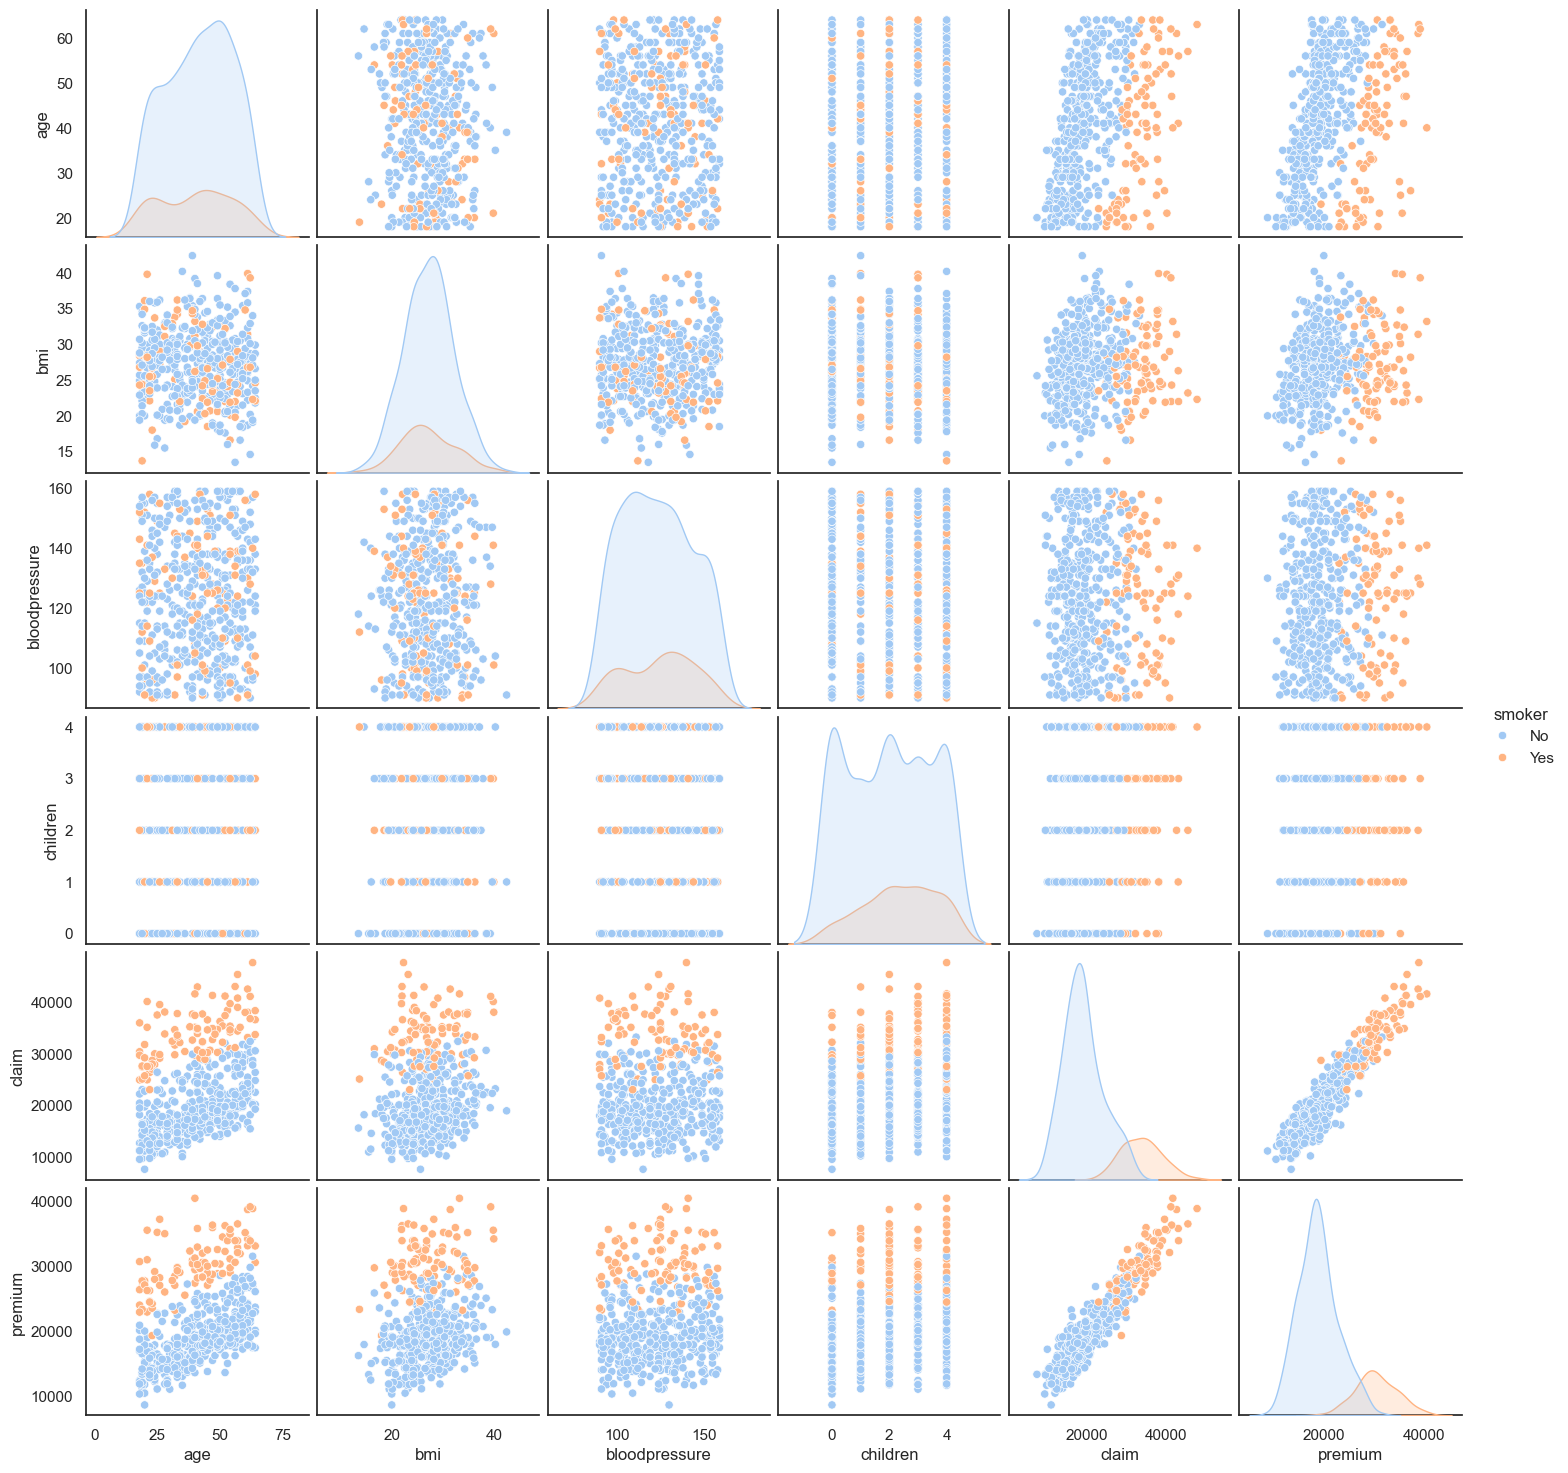

In [78]:
sns.pairplot(df, hue ='smoker')

The pairwise relationships highlight some clear patterns: age, BMI, and blood pressure show scattered but distinguishable distributions, while the strongest positive correlation is between claims and premiums. Smokers generally appear with higher claim amounts and premiums compared to non‑smokers, reinforcing the impact of smoking on costs.

In [75]:
correlation= numerical_cols.corr()
correlation

,age,bmi,bloodpressure,children,claim,charges
age,1.000000,-0.068394,-0.008912,0.107828,0.332181,0.383241
bmi,-0.068394,1.000000,0.027774,-0.009208,0.156835,0.182035
bloodpressure,-0.008912,0.027774,1.000000,-0.044803,0.025294,0.079201
children,0.107828,-0.009208,-0.044803,1.000000,0.213224,0.210420
claim,0.332181,0.156835,0.025294,0.213224,1.000000,0.937747
charges,0.383241,0.182035,0.079201,0.210420,0.937747,1.000000


Claims and charges show a very strong positive correlation, while other variables have weak or negligible relationships.

### Q24: What does the correlation heatmap reveal?

<Axes: >

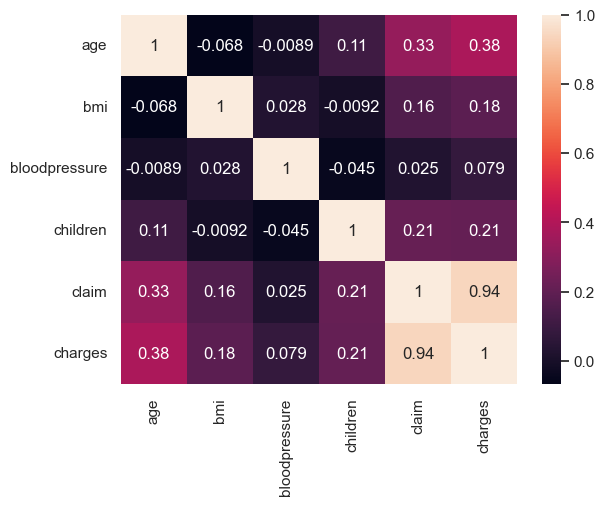

In [80]:
sns.heatmap(correlation, annot =True)

Claims and charges are strongly linked, while other variables show weak correlations.

### Q25: Which feature is most correlated with premium?

In [90]:
corr= correlation['charges'].sort_values(ascending= False).reset_index()
corr

,index,charges
0,charges,1.000000
1,claim,0.937747
2,age,0.383241
3,children,0.210420
4,bmi,0.182035
5,bloodpressure,0.079201


In [91]:
corr.loc[1]

index         claim
charges    0.937747
Name: 1, dtype: object

The feature most strongly correlated with premium is **claim**, with a correlation value of about **0.94**. Other variables like age, children, BMI, and blood pressure show much weaker relationships.
    

### Q26: How does age vs premium differ by smoking status?

<Axes: xlabel='age', ylabel='premium'>

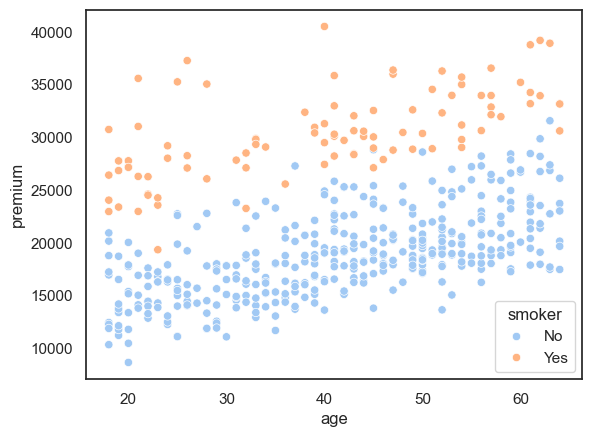

In [83]:
sns.scatterplot(x='age',y='premium' , data= df, hue= 'smoker')

Smokers consistently face higher premiums across all ages compared to non‑smokers, showing that smoking status amplifies costs regardless of age.

### Q27: What is the average premium for smokers vs non-smokers?

In [84]:
df.groupby('smoker')['premium'].mean()

smoker
No     18769.167802
Yes    30398.785579
Name: premium, dtype: float64

### Q28: What is the average premium by region?

In [85]:
df.groupby('region')['premium'].mean()

region
northeast    21206.621838
northwest    21152.372049
southeast    20409.168605
southwest    21167.476814
Name: premium, dtype: float64

### Q29: What is the average premium by gender?

In [86]:
df.groupby('gender')['premium'].mean()

gender
female    20933.338559
male      21017.206863
Name: premium, dtype: float64

### Q30: What is the average premium by number of children?

In [87]:
df.groupby('children')['premium'].mean()

children
0    18599.655288
1    20460.554615
2    21381.432321
3    22072.933980
4    22233.724352
Name: premium, dtype: float64